In [10]:
import torch
from transformers import ElectraTokenizer, ElectraForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np

# 1. 환경 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "monologg/koelectra-base-v3-discriminator"


In [2]:
import pandas as pd
from scipy.stats import boxcox
from sklearn.model_selection import train_test_split
# 1. 데이터 불러오기
df = pd.read_csv("data_cleaned_Mon_5_45M.csv")

# 2. 데이터 확인
print(df.head())
print(df.info())

continuous_cols = [
    'travelDurationMinutes',
    'fare_per_minute'
]

# 2. IQR 사분위수로 
Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. 이상치 제거 마스크 적용
mask = ~((df[continuous_cols] < lower_bound) | (df[continuous_cols] > upper_bound)).any(axis=1)
df_cleaned = df[mask].copy()


   isBasicEconomy  isNonStop  baseFare  seatsRemaining  totalTravelDistance  \
0           False       True    305.12               7               1115.0   
1            True       True    110.70               9                725.0   
2           False       True    189.77               7                339.0   
3           False      False    293.95               9               1671.0   
4            True      False    184.19               9               2674.0   

   departure_hour  days_before_departure  hour_0~6  hour_6~12  hour_12~18  \
0               7                     41         0          1           0   
1               8                     10         0          1           0   
2              17                     54         0          0           1   
3              14                     47         0          0           1   
4               6                      7         0          1           0   

   hour_18~24  stop_count  cabin_score  travelDurationMinutes 

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy.special import inv_boxcox
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

# === Box-Cox 적용을 위한 준비 ===
from scipy.stats import boxcox

# baseFare > 0 필터링
df_boxcox = df_cleaned[df_cleaned['baseFare'] > 0].copy()

# Box-Cox 변환 적용 -> y값은 이제 boxcox_baseFare를 쓸거임.
df_boxcox['boxcox_baseFare'], fitted_lambda = boxcox(df_boxcox['baseFare'])


drop_cols = ['baseFare', 'boxcox_baseFare', 'log_baseFare', 'fare_per_minute','via_count']

# 존재하는 컬럼만 제거
existing = [col for col in drop_cols if col in df_boxcox.columns]
X = df_boxcox.drop(columns=existing)

# 종속변수는 제거 전 데이터에서 꺼내야 함
y = df_boxcox['boxcox_baseFare']

# === 데이터 분할 (7:1:2) ===
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

model = XGBRegressor(subsample= 0.8, 
                     reg_lambda= 1.0,
                     reg_alpha= 0, 
                     n_estimators= 700, 
                     min_child_weight= 1, 
                     max_depth= 6, 
                     learning_rate= 0.2, 
                     gamma= 0.1, 
                     colsample_bytree= 1.0)

model.fit(X_train, y_train)

# 예측 및 평가 Box-Cox 단위
y_valid_pred = model.predict(X_valid)
y_test_pred = model.predict(X_test)

mse_valid = mean_squared_error(y_valid, y_valid_pred)
r2_valid = r2_score(y_valid, y_valid_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\n XGBoost - Box-Cox 기준 성능:")
print(f"Validation MSE: {mse_valid:.4f}")
print(f"Validation R²:  {r2_valid:.4f}")
print(f"Test MSE:       {mse_test:.4f}")
print(f"Test R²:        {r2_test:.4f}")

# === 역변환 후 성능 평가 (실제 요금 기준) ===
# y_test → index는 유지되고 있으므로 df_boxcox에서 baseFare 사용
y_test_pred_original = inv_boxcox(y_test_pred, fitted_lambda)
y_test_original = df_boxcox.loc[y_test.index, 'baseFare']

mse_original = mean_squared_error(y_test_original, y_test_pred_original)
r2_original = r2_score(y_test_original, y_test_pred_original)

print("\n XGBoost - 실제 baseFare 단위 성능:")
print(f"Test MSE:       {mse_original:.4f}")
print(f"Test R²:        {r2_original:.4f}")


NameError: name 'df_cleaned' is not defined

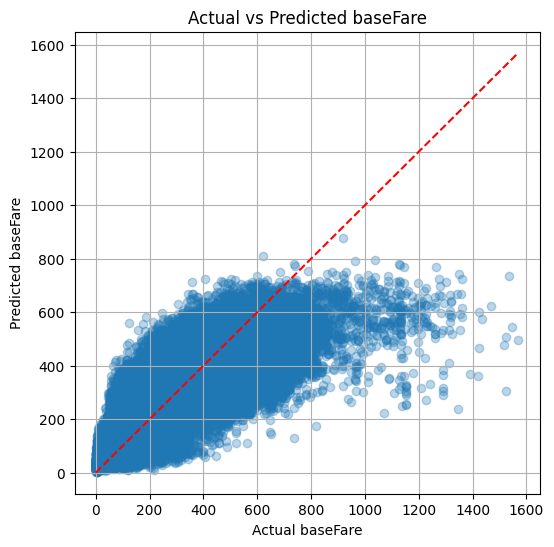

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test_original, y_test_pred_original, alpha=0.3)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         color='red', linestyle='--')
plt.xlabel("Actual baseFare")
plt.ylabel("Predicted baseFare")
plt.title("Actual vs Predicted baseFare")
plt.grid()
plt.show()


In [ ]:
"""(
    subsample= 0.8,                 
    reg_lambda= 1.2,
    reg_alpha= 0.1, 
    n_estimators= 500, 
    min_child_weight= 1, 
    max_depth= 3, 
    learning_rate= 0.1, 
    gamma= 0, 
    colsample_bytree= 0.8
    
     XGBoost - Box-Cox 기준 성능:
    Validation MSE: 19.1565
    Validation R²:  0.6863
    Test MSE:       18.9374
    Test R²:        0.6865
     XGBoost - 실제 baseFare 단위 성능:
    Test MSE:       9519.0616
    Test R²:        0.6464
)"""


"""model = XGBRegressor(subsample= 1.0, 
                     reg_lambda= 1.2,
                     reg_alpha= 0.1, 
                     n_estimators= 300, 
                     min_child_weight= 1, 
                     max_depth= 10, 
                     learning_rate= 0.2, 
                     gamma= 0.1, 
                     colsample_bytree= 0.8)
 XGBoost - Box-Cox 기준 성능:
Validation MSE: 13.8037
Validation R²:  0.7740
Test MSE:       13.7385
Test R²:        0.7726

 XGBoost - 실제 baseFare 단위 성능:
Test MSE:       6989.3461
Test R²:        0.7404
성능은 어느정도 나오게 되었지만 MSE의 값이 너무 높고
깊이가 10은 너무 깊어서 과적합 문제가 생길 수 있음
subsample도 1.0은 과적합 가능성 높음
"""

"""
model = XGBRegressor(subsample= 0.7, 
                     reg_lambda= 1.2,
                     reg_alpha= 0.1, 
                     n_estimators= 300, 
                     min_child_weight= 6, 
                     max_depth= 10, 
                     learning_rate= 0.1, 
                     gamma= 0.1, 
                     colsample_bytree= 0.8)
 XGBoost - Box-Cox 기준 성능:
Validation MSE: 14.3976
Validation R²:  0.7642
Test MSE:       14.3041
Test R²:        0.7632

 XGBoost - 실제 baseFare 단위 성능:
Test MSE:       7268.1616
Test R²:        0.7300
실제 baseFare의 MSE 값이 높고 성능도 떨어짐
subsample은 0.7~0.9, n_estimators 300~700, depth 4~6 사이의 값으로 해야지 과적합X

"""
"""
model = XGBRegressor(subsample= 0.9, 
                     reg_lambda= 1.0,
                     reg_alpha= 0.1, 
                     n_estimators= 500, 
                     min_child_weight= 1, 
                     max_depth= 10, 
                     learning_rate= 0.2, 
                     gamma= 0.1, 
                     colsample_bytree= 0.8)
 XGBoost - Box-Cox 기준 성능:
Validation MSE: 13.7575
Validation R²:  0.7747
Test MSE:       13.6133
Test R²:        0.7746

 XGBoost - 실제 baseFare 단위 성능:
Test MSE:       6911.2515
Test R²:        0.7433
이상치 제거를 안했는데 높은 수치가 나옴
"""

In [13]:
#ada부스트
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# === Box-Cox 적용을 위한 준비 ===
from scipy.stats import boxcox
from scipy.special import inv_boxcox

# baseFare > 0 필터링
df_boxcox = df_cleaned[df_cleaned['baseFare'] > 0].copy()

# Box-Cox 변환 적용 -> y값은 이제 boxcox_baseFare를 쓸거임.
df_boxcox['boxcox_baseFare'], fitted_lambda = boxcox(df_boxcox['baseFare'])

drop_cols = ['baseFare', 'boxcox_baseFare', 'log_baseFare', 'fare_per_minute','via_count']

# 존재하는 컬럼만 제거
existing = [col for col in drop_cols if col in df_boxcox.columns]
X = df_boxcox.drop(columns=existing)

# 종속변수는 제거 전 데이터에서 꺼내야 함
y = df_boxcox['boxcox_baseFare']
    
# 데이터 분할
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

# AdaBoost 모델 구성 및 학습
base_estimator = DecisionTreeRegressor(max_depth=8)
ada = AdaBoostRegressor(estimator=base_estimator, n_estimators=100, learning_rate=0.1, random_state=42)
ada.fit(X_train, y_train)

# 예측 및 평가
y_val_pred = ada.predict(X_val)
y_test_pred = ada.predict(X_test)

print("Validation MSE:", mean_squared_error(y_val, y_val_pred))
print("Validation R²:", r2_score(y_val, y_val_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))
print("Test R²:", r2_score(y_test, y_test_pred))

# === 역변환 후 성능 평가 (실제 요금 기준) ===
# y_test → index는 유지되고 있으므로 df_boxcox에서 baseFare 사용
y_test_pred_original = inv_boxcox(y_test_pred, fitted_lambda)
y_test_original = df_boxcox.loc[y_test.index, 'baseFare']

mse_original = mean_squared_error(y_test_original, y_test_pred_original)
r2_original = r2_score(y_test_original, y_test_pred_original)

print("\n ada부스트 - 실제 baseFare 단위 성능:")
print(f"Test MSE:       {mse_original:.4f}")
print(f"Test R²:        {r2_original:.4f}")

Validation MSE: 21.38075221105406
Validation R²: 0.6499819156263644
Test MSE: 21.141267513296025
Test R²: 0.6500253141725638

 ada부스트 - 실제 baseFare 단위 성능:
Test MSE:       10564.1238
Test R²:        0.6076


최종 전처리 후

In [2]:
import pandas as pd
from scipy.stats import boxcox
from sklearn.model_selection import train_test_split
# 1. 데이터 불러오기
df = pd.read_csv("Final_cleaned_data.csv")

# 2. 데이터 확인
print(df.head())
print(df.info())

continuous_cols = [
    'travelDurationMinutes',
    'start_humidity',
    'start_windgust',
    'start_windspeed', 
    'destin_humidity', 
    'destin_windgust', 
    'destin_windspeed',
]

# 2. IQR 사분위수로 
Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. 이상치 제거 마스크 적용
mask = ~((df[continuous_cols] < lower_bound) | (df[continuous_cols] > upper_bound)).any(axis=1)
df_cleaned = df[mask].copy()

# 4. 결과 요약 출력
print(f"제거 전 샘플 수: {len(df)}")
print(f"제거 후 샘플 수: {len(df_cleaned)}")
print(f"제거된 샘플 수: {len(df) - len(df_cleaned)}")

#  일단 주석처리함,
# 이상치 제거된 데이터 저장
# df_cleaned.to_csv("data_cleaned_no_outliers.csv", index=False)


df['start_temp'] = df['start_temp'] * 9/5 + 32
df['start_feelslike'] = df['start_feelslike'] * 9/5 + 32

df['destin_temp'] = df['start_temp'] * 9/5 + 32
df['destin_feelslike'] = df['start_feelslike'] * 9/5 + 32

   isBasicEconomy  isNonStop  baseFare  seatsRemaining  totalTravelDistance  \
0           False       True    305.12               7               1115.0   
1            True       True    110.70               9                725.0   
2           False       True    189.77               7                339.0   
3           False      False    293.95               9               1671.0   
4            True      False    184.19               9               2674.0   

       cpi     ppi  unemployment_rate  travelDurationMinutes  start_temp  ...  \
0  288.582  265.31                3.7                    171        27.9  ...   
1  288.582  265.31                3.7                    123        16.9  ...   
2  288.582  265.31                3.7                     84        21.1  ...   
3  288.582  265.31                3.7                    434        16.4  ...   
4  288.582  265.31                3.7                    550        10.6  ...   

   airline_score  destin_temp  destin_

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import xgboost as xgb
import shap

# 1. 데이터 전처리 분할 후 Box-Cox 적용
def preprocess_split_boxcox(df):
    df = df[df['baseFare'] > 0].copy()
    X = df.drop(columns=['baseFare'])
    y = df['baseFare']
    return train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Box-Cox 변환 훈련 데이터에만 적합
def apply_boxcox(y_train, y_valid, y_test):
    y_train_bc, fitted_lambda = boxcox(y_train)
    y_valid_bc = boxcox(y_valid, lmbda=fitted_lambda)
    y_test_bc = boxcox(y_test, lmbda=fitted_lambda)
    return y_train_bc, y_valid_bc, y_test_bc, fitted_lambda

# 3. 스케일링
def scale_data(X_train, X_valid, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_valid), scaler.transform(X_test), scaler

# 4. 모델 학습
def train_model(X_train_scaled, y_train, X_valid_scaled, y_valid, params):
    dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
    dvalid = xgb.DMatrix(X_valid_scaled, label=y_valid)
    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=900,
        evals=[(dtrain, "train"), (dvalid, "valid")],
        early_stopping_rounds=30,
        verbose_eval=True
    )
    return model


from sklearn.metrics import mean_absolute_percentage_error

def evaluate_model(model, X_valid_scaled, y_valid, X_test_scaled, y_test, fitted_lambda, y_test_original):
    y_valid_pred = model.predict(xgb.DMatrix(X_valid_scaled))
    y_test_pred = model.predict(xgb.DMatrix(X_test_scaled))

    # Box-Cox 기준
    mse_valid = mean_squared_error(y_valid, y_valid_pred)
    r2_valid = r2_score(y_valid, y_valid_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print("\n XGBoost - Box-Cox 기준 성능:")
    print(f"Validation MSE: {mse_valid:.4f}")
    print(f"Validation R²:  {r2_valid:.4f}")
    print(f"Test MSE:       {mse_test:.4f}")
    print(f"Test R²:        {r2_test:.4f}")

    print("\nBox-Cox 공간 기준 성능")
    print(f"Validation RMSE: {np.sqrt(mse_valid):.4f}")
    print(f"Test RMSE:       {np.sqrt(mse_test):.4f}")

    # 역변환 후 실제 baseFare 기준 평가
    y_test_pred_orig = inv_boxcox(y_test_pred, fitted_lambda)
    mse_orig = mean_squared_error(y_test_original, y_test_pred_orig)
    r2_orig = r2_score(y_test_original, y_test_pred_orig)
    mape_orig = mean_absolute_percentage_error(y_test_original, y_test_pred_orig)

    print("\n 실제 baseFare 기준 성능:")
    print(f"Test MSE:  {mse_orig:.4f}")
    print(f"Test R²:   {r2_orig:.4f}")
    print(f"Test MAPE: {mape_orig:.4f}")


# 6. 교차검증 (Box-Cox 및 스케일링 포함)
def cross_validate_xgb(X, y, params, n_splits=5, num_boost_round=900, early_stopping_rounds=30):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rmse_list = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X)):
        print(f"\n Fold {fold + 1}")
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        y_train_bc, fitted_lambda = boxcox(y_train)
        y_valid_bc = boxcox(y_valid, lmbda=fitted_lambda)

        X_train_scaled, X_valid_scaled, _, _ = scale_data(X_train, X_valid, X_valid)

        dtrain = xgb.DMatrix(X_train_scaled, label=y_train_bc)
        dvalid = xgb.DMatrix(X_valid_scaled, label=y_valid_bc)

        model = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=num_boost_round,
            evals=[(dvalid, "valid")],
            early_stopping_rounds=early_stopping_rounds,
            verbose_eval=False
        )

        y_pred_bc = model.predict(dvalid)
        rmse = np.sqrt(mean_squared_error(y_valid_bc, y_pred_bc))
        print(f"Fold RMSE: {rmse:.4f}")
        rmse_list.append(rmse)

    print(f"\n 평균 RMSE: {np.mean(rmse_list):.4f} ± {np.std(rmse_list):.4f}")
    return np.mean(rmse_list), np.std(rmse_list)
    # 하이퍼파라미터
params = {
    "objective": "reg:squarederror",
    "subsample": 0.8,
    "reg_lambda": 1.2,
    "reg_alpha": 0.01,
    "max_depth": 7,
    "learning_rate": 0.1,
    "gamma": 0.3,
    "colsample_bytree": 1.0,
    "min_child_weight": 3,
    "eval_metric": "rmse",
    "tree_method": "gpu_hist",        # GPU 사용
    "predictor": "gpu_predictor"
}


In [15]:
# 실행 흐름
X_train, X_temp, y_train, y_temp = train_test_split(df_cleaned[df_cleaned['baseFare'] > 0].drop('baseFare', axis=1), df_cleaned[df_cleaned['baseFare'] > 0]['baseFare'], test_size=0.2, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Box-Cox
y_train_bc, y_valid_bc, y_test_bc, fitted_lambda = apply_boxcox(y_train, y_valid, y_test)

# 스케일링
X_train_scaled, X_valid_scaled, X_test_scaled, scaler = scale_data(X_train, X_valid, X_test)

# 학습 및 평가
model = train_model(X_train_scaled, y_train_bc, X_valid_scaled, y_valid_bc, params)
evaluate_model(model, X_valid_scaled, y_valid_bc, X_test_scaled, y_test_bc, fitted_lambda, y_test)

# 교차검증
cross_validate_xgb(df_cleaned[df_cleaned['baseFare'] > 0].drop('baseFare', axis=1), df_cleaned[df_cleaned['baseFare'] > 0]['baseFare'], params)


[0]	train-rmse:5.48862	valid-rmse:5.47326
[1]	train-rmse:5.18949	valid-rmse:5.17785
[2]	train-rmse:4.93095	valid-rmse:4.92327
[3]	train-rmse:4.70918	valid-rmse:4.70522
[4]	train-rmse:4.51951	valid-rmse:4.51872
[5]	train-rmse:4.35493	valid-rmse:4.35773
[6]	train-rmse:4.21736	valid-rmse:4.22334
[7]	train-rmse:4.09853	valid-rmse:4.10762
[8]	train-rmse:3.99962	valid-rmse:4.01145
[9]	train-rmse:3.91303	valid-rmse:3.92723
[10]	train-rmse:3.83825	valid-rmse:3.85446
[11]	train-rmse:3.77578	valid-rmse:3.79429
[12]	train-rmse:3.71713	valid-rmse:3.73778
[13]	train-rmse:3.66889	valid-rmse:3.69128
[14]	train-rmse:3.62878	valid-rmse:3.65242
[15]	train-rmse:3.59141	valid-rmse:3.61662
[16]	train-rmse:3.55838	valid-rmse:3.58541
[17]	train-rmse:3.53031	valid-rmse:3.55923
[18]	train-rmse:3.50775	valid-rmse:3.53822
[19]	train-rmse:3.48623	valid-rmse:3.51764
[20]	train-rmse:3.46748	valid-rmse:3.50003
[21]	train-rmse:3.45014	valid-rmse:3.48388
[22]	train-rmse:3.43394	valid-rmse:3.46888
[23]	train-rmse:3.417

(np.float64(2.654770526931103), np.float64(0.032168788470233606))

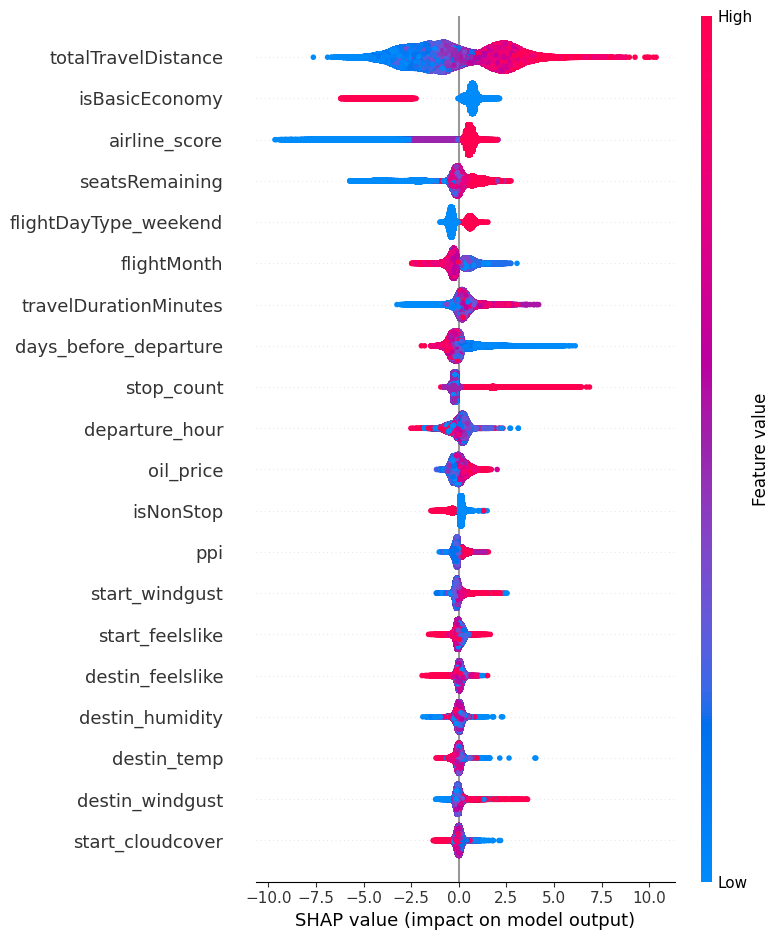

In [32]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_scaled)

shap.summary_plot(shap_values, X_train_scaled, feature_names=X.columns)


In [13]:
import pandas as pd
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import numpy as np

# -------------------------------
# 1. 데이터 준비 (baseFare > 0)
# -------------------------------
df_boxcox = df[df['baseFare'] > 0].copy()
X = df_boxcox.drop(columns=['baseFare'])
y = df_boxcox['baseFare']

# -------------------------------
# 2. 데이터 분할
# -------------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

# -------------------------------
# 3. Box-Cox 변환
# -------------------------------
y_train_bc, fitted_lambda = boxcox(y_train)
y_val_bc = boxcox(y_val, lmbda=fitted_lambda)
y_test_bc = boxcox(y_test, lmbda=fitted_lambda)

# -------------------------------
# 4. 스케일링
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# 5. 하이퍼파라미터 탐색
# -------------------------------
base_est = DecisionTreeRegressor(random_state=42)
ada = AdaBoostRegressor(estimator=base_est, random_state=42)

param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'estimator__max_depth': [2, 3, 5]
}

# GridSearchCV: Box-Cox 공간의 MSE 기준
grid = GridSearchCV(ada, param_grid, scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train_bc)

print("최적 파라미터:", grid.best_params_)

# -------------------------------
# 6. 최적 모델 성능 평가
# -------------------------------
best_model = grid.best_estimator_

# 예측
y_val_pred_bc = best_model.predict(X_val_scaled)
y_test_pred_bc = best_model.predict(X_test_scaled)

# Box-Cox 공간에서 성능
print("\n Box-Cox 변환 기준 성능")
print(f"Validation MSE: {mean_squared_error(y_val_bc, y_val_pred_bc):.4f}")
print(f"Validation R² : {r2_score(y_val_bc, y_val_pred_bc):.4f}")
print(f"Test MSE      : {mean_squared_error(y_test_bc, y_test_pred_bc):.4f}")
print(f"Test R²       : {r2_score(y_test_bc, y_test_pred_bc):.4f}")

# -------------------------------
# 7. 역변환 후 실제 단위에서 성능 평가
# -------------------------------
y_test_pred = inv_boxcox(y_test_pred_bc, fitted_lambda)

mse_real = mean_squared_error(y_test, y_test_pred)
r2_real = r2_score(y_test, y_test_pred)
mape_real = mean_absolute_percentage_error(y_test, y_test_pred)

print("\n 실제 단위(baseFare) 기준 성능")
print(f"Test MSE : {mse_real:.4f}")
print(f"Test R²  : {r2_real:.4f}")   

print(f"Test MAPE: {mape_real:.4f}")


Fitting 3 folds for each of 18 candidates, totalling 54 fits
최적 파라미터: {'estimator__max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 100}

 Box-Cox 변환 기준 성능
Validation MSE: 13.4842
Validation R² : 0.5816
Test MSE      : 13.4731
Test R²       : 0.5832

 실제 단위(baseFare) 기준 성능
Test MSE : 15761.9476
Test R²  : 0.5271
Test MAPE: 0.5837


In [20]:
from sklearn.model_selection import KFold
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import boxcox
from scipy.special import inv_boxcox

def cross_validate_adaboost(X, y, n_splits=3, n_estimators=500, learning_rate=0.1, max_depth=3):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rmse_list = []
    rmse_orig_list = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X)):
        print(f"\n Fold {fold + 1}")

        # 데이터 분할
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        # Box-Cox
        y_train_bc, fitted_lambda = boxcox(y_train)
        y_valid_bc = boxcox(y_valid, lmbda=fitted_lambda)

        # 스케일링
        X_train_scaled, X_valid_scaled, _, _ = scale_data(X_train, X_valid, X_valid)

        # 모델 정의 및 학습
        base_estimator = DecisionTreeRegressor(max_depth=max_depth)
        ada = AdaBoostRegressor(
            estimator=base_estimator,
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=42
        )
        ada.fit(X_train_scaled, y_train_bc)

        # 예측
        y_pred_bc = ada.predict(X_valid_scaled)
        y_pred_orig = inv_boxcox(y_pred_bc, fitted_lambda)

        # 성능 평가 (Box-Cox 공간)
        rmse_bc = np.sqrt(mean_squared_error(y_valid_bc, y_pred_bc))
        rmse_list.append(rmse_bc)

        # 성능 평가 (실제 baseFare 기준)
        rmse_orig = np.sqrt(mean_squared_error(y_valid, y_pred_orig))
        rmse_orig_list.append(rmse_orig)

        print(f"RMSE (Box-Cox): {rmse_bc:.4f} | RMSE (Original): {rmse_orig:.4f}")

    print("\n 평균 성능:")
    print(f"Box-Cox RMSE: {np.mean(rmse_list):.4f} ± {np.std(rmse_list):.4f}")
    print(f"Original RMSE: {np.mean(rmse_orig_list):.4f} ± {np.std(rmse_orig_list):.4f}")

    return np.mean(rmse_list), np.mean(rmse_orig_list)


In [21]:

# 전처리
df_boxcox = df[df['baseFare'] > 0].copy()
X = df_boxcox.drop(columns=['baseFare'])
y = df_boxcox['baseFare']

# 교차검증 실행
cross_validate_adaboost(X, y)



 Fold 1
RMSE (Box-Cox): 4.7460 | RMSE (Original): 152.2908

 Fold 2
RMSE (Box-Cox): 4.4744 | RMSE (Original): 142.8449

 Fold 3
RMSE (Box-Cox): 4.3192 | RMSE (Original): 138.8392

 평균 성능:
Box-Cox RMSE: 4.5132 ± 0.1764
Original RMSE: 144.6583 ± 5.6393


(np.float64(4.513226395239719), np.float64(144.65828319777214))

In [24]:
# 테스트 데이터 전처리
test_df = pd.read_csv("test_1000_final.csv")
test_df = test_df[test_df["baseFare"] > 0].copy()
test_df.columns = [col.replace("hour__", "hour_") for col in test_df.columns]

# 정답 저장
y_test_real = test_df["baseFare"].copy()

# 피처 정렬 및 스케일링
X_test_real = test_df[X.columns]  # 학습 시 사용한 X.columns 순서 그대로!
X_test_real_scaled = scaler.transform(X_test_real)
dtest_real = xgb.DMatrix(X_test_real_scaled)

# 예측 및 역변환
y_pred_bc = xgb_model.predict(dtest_real)
y_pred = inv_boxcox(y_pred_bc, fitted_lambda)

# 평가
mse = mean_squared_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)
mape = mean_absolute_percentage_error(y_test_real, y_pred)

print("\n XGBoost 모델 - test_1000_final.csv 평가 결과:")
print(f"Test MSE  : {mse:.4f}")
print(f"Test R²   : {r2:.4f}")
print(f"Test MAPE : {mape:.2%}")



 XGBoost 모델 - test_1000_final.csv 평가 결과:
Test MSE  : 7412.1524
Test R²   : 0.7744
Test MAPE : 30.37%


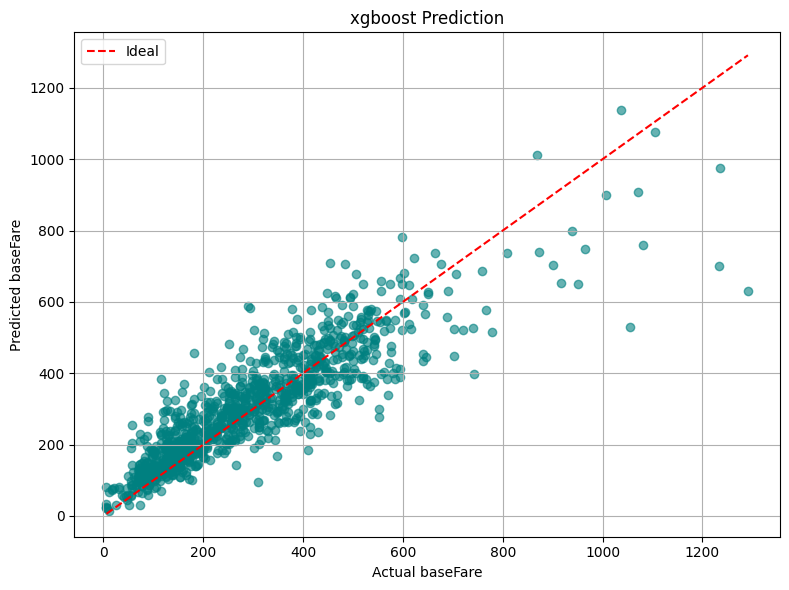

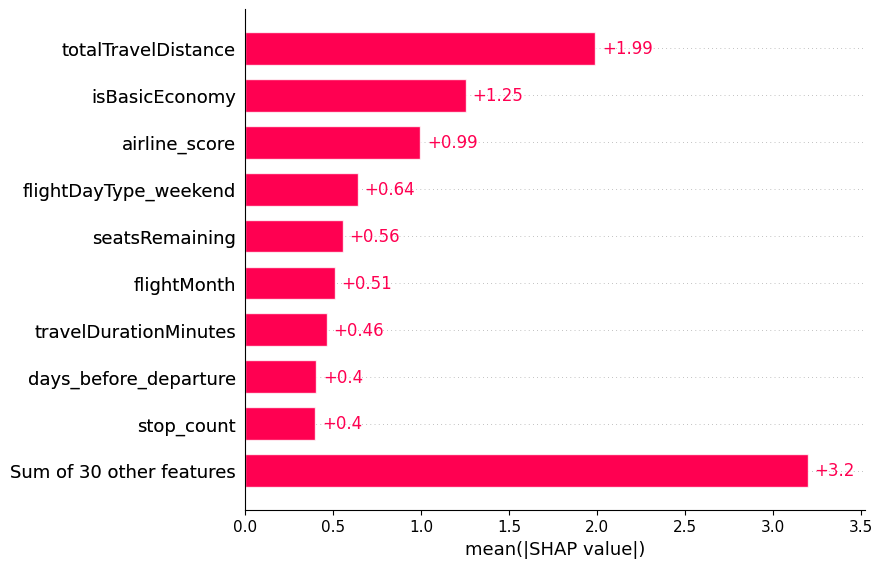


Top 10 mean(|SHAP value|):
totalTravelDistance      1.9887
isBasicEconomy           1.2537
airline_score            0.9943
flightDayType_weekend    0.6374
seatsRemaining           0.5551
flightMonth              0.5072
travelDurationMinutes    0.4618
days_before_departure    0.4022
stop_count               0.3980
departure_hour           0.3358
dtype: float32


In [32]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Ideal')
plt.xlabel("Actual baseFare")
plt.ylabel("Predicted baseFare")
plt.title("xgboost Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# X_test_scaled를 DataFrame으로 변환 (컬럼 이름은 X_test에서 가져오기)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# SHAP 설명자 생성 및 계산
explainer = shap.Explainer(model)
shap_values = explainer(X_test_scaled_df)

# SHAP 시각화 (bar plot)
shap.plots.bar(shap_values)

# SHAP 상위 10개 평균 절댓값 출력
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

print("\nTop 10 mean(|SHAP value|):")
print(mean_abs_shap.head(10).round(4))


In [21]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error, mean_absolute_percentage_error

# test 데이터 불러오기
test_df = pd.read_csv("test_1000_final.csv")
test_df = test_df[test_df['baseFare'] > 0].copy()

# feature_list 순서대로 test 데이터 준비
remove_cols = ['state']
drop_cols = [col for col in remove_cols + ['baseFare'] if col in test_df.columns]
X_test = test_df.drop(columns=drop_cols)

# 학습 시 사용한 컬럼 순서와 동일하게 정렬
X_test = X_test[X_train.columns]
y_test = test_df['baseFare']

# 스케일링
X_test_scaled = scaler.transform(X_test)
dtest = xgb.DMatrix(X_test_scaled)

# 예측 (Box-Cox 변환된 상태)
y_pred_bc = model.predict(dtest)

# 역 Box-Cox 변환
y_pred = inv_boxcox(y_pred_bc, fitted_lambda)

# 평가 지표 계산
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# 결과 출력
print("\n[test_1000_final.csv 평가 결과]")
print(f"MSE       : {mse:.4f}")
print(f"R²        : {r2:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"Median AE : {medae:.4f}")
print(f"MAPE      : {mape:.2%}")



[test_1000_final.csv 평가 결과]
MSE       : 7776.9763
R²        : 0.7633
MAE       : 62.1395
Median AE : 44.3327
MAPE      : 30.73%


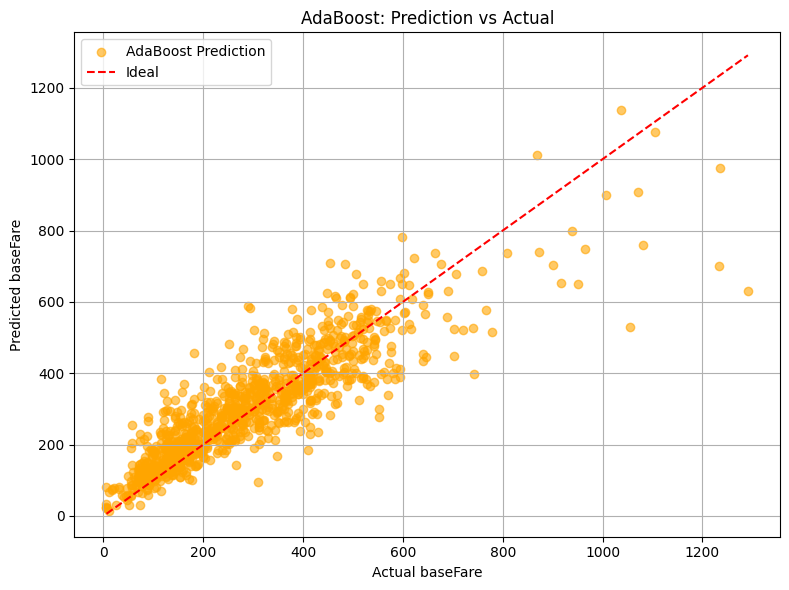

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='orange', label='AdaBoost Prediction')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Ideal')
plt.xlabel("Actual baseFare")
plt.ylabel("Predicted baseFare")
plt.title("AdaBoost: Prediction vs Actual")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.current_device() if torch.cuda.is_available() else "No GPU")
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


2.7.1+cu118
True
0
NVIDIA GeForce RTX 3050 Laptop GPU
